In [15]:
import torch 
import torch.nn as nn
from collections import defaultdict, Counter
import json
import pandas as pd
import matplotlib.pyplot as plt


In [26]:
def generate_last_n_bougth_item(df, N=5):
    df_verified = df[df['verified_purchase'] == True]

    # Sort by user and timestamp descending
    df_verified = df_verified.sort_values(by=['user_id', 'timestamp'], ascending=[True, False])

    # Group by user and get last 5 purchases
    last_N_item = df_verified.groupby('user_id').head(5)
    # Convert to dictionary format: {user_id: [list of item_ids]}
    result_dict = (
        last_N_item
        .sort_values(by=['user_id', 'timestamp'])
        .groupby('user_id')['parent_asin']
        .apply(list)
        .to_dict()
    )
    # Save to JSON file
    with open(f'Data/last_{N}_purchases.json', 'w') as f:
        json.dump(result_dict, f, indent=4)
    print("Saved to last_N_purchases.json")

df = pd.read_excel("Data/top30k_user_labels.xlsx")
generate_last_n_bougth_item(df)

Saved to last_N_purchases.json


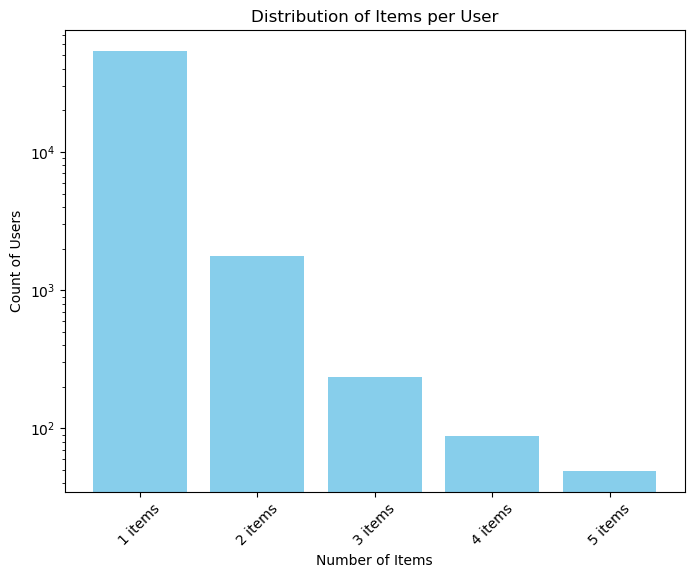

In [23]:
with open('Data/last_5_purchases.json', 'r') as file:
    lastN_data = json.load(file)

# count the number of items in each list
list_lengths = [len(value) for value in lastN_data.values()]

# count how many times each length occurs
length_counts = Counter(list_lengths)
length_counts = dict(sorted(length_counts.items()))
# plot the distribution of list lengths
labels = [f'{length} items' for length in length_counts.keys()]
values = list(length_counts.values())

plt.figure(figsize=(8, 6))
plt.bar(labels, values, color='skyblue')
plt.yscale('log')
plt.xlabel('Number of Items')
plt.ylabel('Count of Users')
plt.title('Distribution of Items per User')
plt.xticks(rotation=45)
plt.show()

In [13]:
import json
# adding pad
# pad to length 5
MAX_LEN = 5
PAD_ID = "<PAD>"
last5 = {}
with open('Data/last_5_purchases.json', 'r') as file:
    lastN_data = json.load(file)
for u, item in lastN_data.items():
    if len(item) > MAX_LEN:
        last5[u] = item[-MAX_LEN]
    else:
        # pad on the left with PAD_ID so that rightmost are real
        pad = [PAD_ID] * (MAX_LEN - len(item))
        last5[u] = pad + item

with open(f'Data/last_5_purchases_withPad.json', 'w') as f:
    json.dump(last5, f, indent=4)


In [14]:
import json
with open(f'Data/last_5_purchases_withPad.json', 'r') as f:
    last5 = json.load(f)
all_valid = all(len(items)==5 for items in last5.values())
unique_lengths = set(len(items) for items in last5.values())
print(unique_lengths)
if all_valid:
    print("all 5")
else:
    print("not all 5")

for u, item in last5.items():
    if len(item) == 10:
        print(f"u:{u}; item:{item}")

{5}
all 5


In [10]:
last5['AHWV4WMKWXYLNN5VHWHW76U3YKGQ']

'B09WGZ4P2Z'

In [11]:
with open(f'Data/last_5_purchases.json', 'r') as f:
    last5_ori = json.load(f)


In [12]:
last5_ori['AHWV4WMKWXYLNN5VHWHW76U3YKGQ']

['B09WGZ4P2Z', 'B0B93W2M9F', 'B09Z2C22N9', 'B09WRJ53HV', 'B0BQBSXQHB']

In [1]:
## Add <PAD> vector into product embeddings
import json
import numpy as np

with open("../RetrievalModel/Data/product_embeddings.json", "r") as f:
    product_emb_dict = json.load(f)

# Get the dimensionality D from one example
first_vector = next(iter(product_emb_dict.values()))
D = len(first_vector)

# Add the <PAD> with zero vector
product_emb_dict['<PAD>'] = [0.0] * D

# Save it back to JSON file
with open("Data/product_embeddings_withPad.json", "w") as f:
    json.dump(product_emb_dict, f, indent=4)


In [2]:
import json
import numpy as np

with open("../RetrievalModel/Data/product_embeddings.json", "r") as f:
    product_emb_dict = json.load(f)

# Get the dimensionality D from one example
first_vector = next(iter(product_emb_dict.values()))
D = len(first_vector)
print(f"product dimension: {D}")

with open("../RetrievalModel/Data/user_embeddings.json", "r") as f:
    use_emb_dict = json.load(f)

# Get the dimensionality D from one example
first_vector = next(iter(use_emb_dict.values()))
D = len(first_vector)
print(f"user dimension: {D}")

product dimension: 128
user dimension: 128


In [3]:
product_emb_dict

{'B0B38YRJKY': [0.014228778,
  -0.0971868,
  -0.0015702134,
  -0.0001748096,
  -0.0009953575,
  0.024097662,
  0.06539768,
  -0.050311238,
  0.0013102388,
  0.00322269,
  -0.004214666,
  0.005306163,
  0.033451043,
  0.0022556907,
  0.019662958,
  -0.040114135,
  0.016040444,
  0.47413892,
  -0.11126994,
  0.1389999,
  0.0030931248,
  -0.1950719,
  -0.019034898,
  -0.043166433,
  0.004015295,
  -0.13330717,
  -0.0034242645,
  0.09834638,
  0.028542858,
  0.04414191,
  -0.000598229,
  -0.14375025,
  0.103561886,
  -0.0033084177,
  0.000339492,
  0.0077393115,
  -0.00408178,
  -0.14510055,
  0.0634298,
  -0.15251505,
  -2.6664115e-05,
  0.0021412252,
  0.042532984,
  0.10192279,
  0.017762043,
  0.04810489,
  0.0017193116,
  -0.0069608763,
  0.16524336,
  0.13191535,
  0.13895708,
  -0.18964325,
  0.12626082,
  -0.09439113,
  0.028384743,
  0.12904787,
  0.0671688,
  -0.0072042374,
  -0.2735454,
  0.055337884,
  -0.1599653,
  0.1468659,
  -0.0018051527,
  0.08513289,
  -0.0056381635,
  -

### generate training set and test set for ranking model

In [1]:
import pandas as pd

In [6]:
df_user = pd.read_excel("./Data/top30k_user_labels.xlsx")
df_train = pd.read_excel("../RetrievalModel/Data/training_set24k.xlsx")
df_test = pd.read_excel("../RetrievalModel/Data/test_set6k.xlsx")
print(df_train.columns)
print(f"user columns: {df_user.columns}")
df_user = df_user[['user_id', 'parent_asin', 'verified_purchase', 'clicked', 'add_to_cart', 'favorite']]
df_train_ranking = pd.merge(df_train, df_user, on='parent_asin')
df_test_ranking = pd.merge(df_test, df_user, on = 'parent_asin')

print(f"train_ranking columns: {df_train_ranking.columns}")
print(f"training shape: {df_train_ranking.shape}")

print(f"testing_ranking columns: {df_test_ranking.columns}; shape: {df_test_ranking.shape}")
df_train_ranking.to_excel("./Data/training_set_ranking65k.xlsx", index=False)
df_test_ranking.to_excel("./Data/testing_set_ranking9k.xlsx", index= False)

Index(['main_category', 'title', 'average_rating', 'rating_number', 'features',
       'description', 'price', 'images', 'videos', 'store', 'categories',
       'details', 'parent_asin', 'bought_together', 'purchase_score', 'data',
       'subtitle', 'author'],
      dtype='object')
user columns: Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase', 'p_click', 'p_cart',
       'p_fav', 'rating_norm', 'helpful_norm', 'p_favorite', 'clicked',
       'add_to_cart', 'favorite'],
      dtype='object')
train_ranking columns: Index(['main_category', 'title', 'average_rating', 'rating_number', 'features',
       'description', 'price', 'images', 'videos', 'store', 'categories',
       'details', 'parent_asin', 'bought_together', 'purchase_score', 'data',
       'subtitle', 'author', 'user_id', 'verified_purchase', 'clicked',
       'add_to_cart', 'favorite'],
      dtype='object')
training shape: (65770, 23)
testi

In [2]:
import random
print(random.choice([1,2,3,4]))
print(random.choice([1,2,3,4]))

3
2


In [24]:
#df_verified['user_id'].value_counts()
last_N_item = df_verified.groupby('user_id').head(5)
result_dict = (
        last_N_item
        .sort_values(by=['user_id', 'timestamp'])
        .groupby('user_id')['parent_asin']
        .apply(list)
        .to_dict()
)
result_dict

{'AE222FP7YRNFCEQ2W3ZDIGMSYTLQ': ['B0BTT658PQ'],
 'AE223N4K4ROAGJPN55UM3IYGGCOQ': ['B09P4S1565'],
 'AE225KTEK4YRJE2TBGPJZEAXAA4Q': ['B0BNQ86BQV'],
 'AE225NQR6TN6SUNMTF6O4T37TXPQ': ['B000HVV2N6'],
 'AE225T2ZALMW2LGAWZGONMYD2VJA': ['B09Y1BWYCR'],
 'AE22DQOTFYYIPCNVZIB4BZW2YZ3Q': ['B0BXCRVZ52'],
 'AE22FGBZZ3B264XLTWV36YYVMJGA': ['B09LYQWL2Q'],
 'AE22ILTJT7J2IQCYY2KDUR7PEOPA': ['B09V3GPZKS'],
 'AE22JIV3CMHYOVXGD3E6R7B45ZOA': ['B0BPPQM2X5', 'B0BPPQM2X5'],
 'AE22K4SIBCPAPJIYOJXRNV2SXH7Q': ['B09W15H84K'],
 'AE22NDIK5WGMCYZVNZVTZPKFH6VA': ['B00G2IZE3W'],
 'AE22NIT4ZVYJPGCK6F67ODZUU2GQ': ['B0B5VTZX1Y'],
 'AE22PJQZBK2FLF5P35OMGHX3BLQQ': ['B09H39RXSC'],
 'AE22RDF72XZIZOE2M23ASFW3IPJQ': ['B0B28HVP2M', 'B0B3DMZCBG'],
 'AE22RIX5MLP4SCGZOTEA4SARKY7Q': ['B0BKSCJFXH'],
 'AE22TLG6DI55S37MEARUHMUJHJIQ': ['B0BRNMMPMS'],
 'AE22UTZWJSJT7Q6UODRV7J5LRSZA': ['B09V2NJYM8'],
 'AE22YVG5SQL5LZXEFFTIZKNKAJIQ': ['B0947RH5B2'],
 'AE235UMYTUAERV6YECQN7ZXQN2LA': ['B09SSX1TRY'],
 'AE2367ZVUZPTQJ3DD675UKZ4GVLA': ['B09YXT

In [21]:
last_N_item

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,p_click,p_cart,p_fav,rating_norm,helpful_norm,p_favorite,clicked,add_to_cart,favorite
15214,5,Nice consistency and great smell,[[VIDEOID:8b3489ae8e6301ceb95a2973d7f721f3]],[],B0BTT658PQ,B0BTT658PQ,AE222FP7YRNFCEQ2W3ZDIGMSYTLQ,2023-03-07 03:10:12.143,0,True,0.700000,0.450000,0.200,1.00,0.000000,0.300000,1,1,0
24004,5,Worth the value,The hair arrived in a beautiful pink silk bag ...,[{'small_image_url': 'https://m.media-amazon.c...,B09P4S1565,B09P4S1565,AE223N4K4ROAGJPN55UM3IYGGCOQ,2022-10-24 04:45:41.918,3,True,0.703529,0.451765,0.200,1.00,0.017647,0.301765,1,1,0
59075,5,"Fit well, good value",This was half the price of a “brand” part and ...,[],B0BNQ86BQV,B0BNQ86BQV,AE225KTEK4YRJE2TBGPJZEAXAA4Q,2023-09-03 16:00:34.739,0,True,0.700000,0.450000,0.200,1.00,0.000000,0.300000,1,1,0
64574,5,Great seller,The product is Awesome and delivered in timely...,[],B000HVV2N6,B000HVV2N6,AE225NQR6TN6SUNMTF6O4T37TXPQ,2022-04-22 22:19:43.971,0,True,0.700000,0.450000,0.200,1.00,0.000000,0.300000,1,1,0
24920,5,Loved it!!,It does exactly what it says! It removed all f...,[],B09Y1BWYCR,B09Y1BWYCR,AE225T2ZALMW2LGAWZGONMYD2VJA,2022-06-08 23:45:33.411,2,True,0.702353,0.451176,0.200,1.00,0.011765,0.301176,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5003,5,La duración,Me agradó todo.,[],B092PTQW9V,B092PTQW9V,AHZZKY3S6YCCJV2VH4HVJ3Y5IEDA,2022-12-22 13:37:08.213,0,True,0.700000,0.450000,0.200,1.00,0.000000,0.300000,1,1,1
57215,5,Fridge Shelf Replacement,Perfect fit and more durable than the original...,[],B0BKT4YYQQ,B0BKT4YYQQ,AHZZLN7P67CN7L4RODX665VBYQXQ,2023-06-23 18:08:09.726,0,True,0.700000,0.450000,0.200,1.00,0.000000,0.300000,1,1,0
56666,5,Easy install,This water line fits good and gives me no issues,[],B0B5P75NVQ,B0B5P75NVQ,AHZZLTXCRUYXU6D7L7RJBWIQWQPA,2023-06-07 02:15:51.921,0,True,0.700000,0.450000,0.200,1.00,0.000000,0.300000,1,1,0
54173,4,"my Maytag needs 5 wheels, kit comes with 4. So...","Not enough wheels, even though my model was li...",[],B0B48X1K71,B0B48X1K71,AHZZMDXZ6ZC26RPBK5WQ77YP7XDQ,2022-11-11 19:30:29.209,0,True,0.600000,0.375000,0.175,0.75,0.000000,0.250000,1,1,0


### PLE model

In [31]:
class SharedBottom(nn.Module):
    def __init__(self, input_dim, shared_dim):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, shared_dim),
            nn.ReLU(),
            nn.Linear(shared_dim, shared_dim)
        )

    def forward(self, x):
        return self.shared(x)

class TaskTower(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.tower = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, 1)
        )

    def forward(self, x):
        return torch.sigmoid(self.tower(x))


### Multi-Head Attention on Last-N features

In [33]:
class MultiHeadSeqAttention(nn.Module):
    def __init__(self, embed_dim, num_heads=2):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)

    def forward(self, item_seq_emb):
        # Self-attention over sequence
        attn_output, _ = self.attn(item_seq_emb, item_seq_emb, item_seq_emb)
        return attn_output.mean(dim=1)  # average pooling over time


### Cross layer (for Two-tower or Wide & Deep)

In [34]:
class CrossLayer(nn.Module):
    def __init__(self, input_dim, num_layers=2):
        super().__init__()
        self.cross_weights = nn.ModuleList([
            nn.Linear(input_dim, 1, bias=False) for _ in range(num_layers)
        ])
        self.cross_biases = nn.ParameterList([
            nn.Parameter(torch.zeros(input_dim)) for _ in range(num_layers)
        ])

    def forward(self, x0):
        x = x0
        for w, b in zip(self.cross_weights, self.cross_biases):
            xw = w(x)
            x = x0 * xw + b + x
        return x


### Feature Embedding

In [35]:
class EmbeddingLayer(nn.Module):
    def __init__(self, user_vocab_size, item_vocab_size, category_vocab_size, embedding_dim):
        super().__init__()
        self.user_emb = nn.Embedding(user_vocab_size, embedding_dim)
        self.item_emb = nn.Embedding(item_vocab_size, embedding_dim)
        self.category_emb = nn.Embedding(category_vocab_size, embedding_dim)

    def forward(self, user_ids, item_ids, category_ids):
        return self.user_emb(user_ids), self.item_emb(item_ids), self.category_emb(category_ids)


### Get last N items

In [36]:
# utils/data_preprocess.py
def generate_last_n_sequences(df, N=5):
    user_sequences = defaultdict(list)
    sequences = []

    df = df.sort_values(by=['user_id', 'timestamp'])

    for _, row in df.iterrows():
        user = row['user_id']
        item = row['item_id']
        label = row['label']

        history = user_sequences[user][-N:]
        sequences.append((user, item, history, label))

        user_sequences[user].append(item)

    return sequences


## Final model

In [ ]:
class RecSysModel(nn.Module):
    def __init__(self, user_vocab, item_vocab, cat_vocab, embed_dim):
        super().__init__()
        self.emb_layer = EmbeddingLayer(user_vocab, item_vocab, cat_vocab, embed_dim)
        self.cross = CrossLayer(embed_dim)
        self.seq_attention = MultiHeadSeqAttention(embed_dim)

        self.shared_bottom = SharedBottom(embed_dim * 4, 128)
        self.purchase_tower = TaskTower(128)
        self.click_tower = TaskTower(128)
        self.cart_tower = TaskTower(128)
        self.favorite_tower = TaskTower(128)

    def forward(self, user_id, item_id, category_id, last_n_item_ids):
        user_emb, item_emb, cat_emb = self.emb_layer(user_id, item_id, category_id)
        last_item_embs = self.emb_layer.item_emb(last_n_item_ids)
        seq_emb = self.seq_attention(last_item_embs)

        features = torch.cat([user_emb, item_emb, cat_emb, seq_emb], dim=-1)
        crossed = self.cross(features)
        shared_out = self.shared_bottom(crossed)

        return {
            "purchase": self.purchase_tower(shared_out),
            "click": self.click_tower(shared_out),
            "cart": self.cart_tower(shared_out),
            "favorite": self.favorite_tower(shared_out),
        }
